# EDA regarding:
* Mean number of slices per patient
* Quantitative analysis regarding tumours in 2D and 3D
* Visual comparison between train and validation
* Contributes to hyperparameter tunning for batch stack size

In the file `./eda1_computational_effort_training.pkl`, we have stored the following matrices:

- `binning_volume`: Splits the stacks into percentage bins and counts the number of tumorous slices in each volume % wise

- `stacks_full_volume`: Splits stacks one by one to MAX_SLICES slices and counts the number of tumorous voxels in each slice of the volume

- `bins_2d`: For each patient, counts the number of tumorous pixels in each 512x512 frame

- `zoomed_bins_2d`: Splits the 2D images into 16x16 patches and counts the number of tumorous pixels in each patch

- `tumor_volume`: Counts the number of tumorous voxels in each patient compared to the total number of voxels

- `slices_per_patient`: Counts the number of slices in each patient


As it takes 3 hours to generate those on the original dataset

# Install

In [1]:
# !pip install -q "monai-weekly[nibabel, skimage, scipy, pillow, tensorboard, gdown, ignite, torchvision, itk, tqdm, lmdb, psutil, cucim, openslide, pandas, einops, transformers, mlflow, clearml, matplotlib, tensorboardX, tifffile, imagecodecs, pyyaml, fire, jsonschema, ninja, pynrrd, pydicom, h5py, nni, optuna, onnx, onnxruntime, zarr, lpips, pynvml, huggingface_hub]"

# Import libraries

In [17]:
import os
import warnings
warnings.filterwarnings("ignore") # remove some scikit-image warnings

from monai.metrics import DiceMetric, MeanIoU, compute_average_surface_distance, DiceHelper
from sklearn.metrics import precision_score, recall_score


from monai.apps import DecathlonDataset
from monai.data import DataLoader
from monai.transforms import (
    LoadImageD,
    Compose,
    LoadImageD,
)

import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# Types

#### Set seeds

In [7]:
import sys
from tqdm import tqdm
import pickle as pkl

In [8]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

### Hyperparameters

In [12]:
crt_dir = os.getcwd()

datasets_path = f'{crt_dir}/datasets/MedicalDecathlon/'

In [13]:
from eda_src.types import *

from eda_src.read_msd_functions import read_msd, read_memoized_data

## VALIDATION

In [14]:
# Set up transform
KEYS = ["image", "label"]

base_transform = Compose([
    LoadImageD(keys=KEYS),
])

In [15]:
# Load dataset
memoized_path = f'/raid/CataChiru/MedicalDecathlonTensors'
val_name = 'validation'

val_name, validation_on_ds_type, val_dataset, val_loader = read_msd(memoized_path, val_name, base_transform)

Loading memoized data


In [16]:
dice_metric_eval = DiceHelper(include_background = False, reduction = "mean", get_not_nans=False, ignore_empty=True) # include_background = False,


In [74]:
dice_val = []
precision_val = []
recall_val = []

low_bound = -250
high_bound = 300


for i in range(len(val_dataset)):
    print(i+1, len(val_dataset))
    # Returns 1 for values within the bounds, 0 for values outside
    filtered_patient = torch.where(((low_bound <= val_dataset[i]['image']) & (val_dataset[i]['image'] <= high_bound)), 1, 0)

    dice_val.append(dice_metric_eval(filtered_patient, val_dataset[i]['label']).item())
    precision_val.append(precision_score(val_dataset[i]['label'].flatten(), filtered_patient.flatten()))
    recall_val.append(recall_score(val_dataset[i]['label'].flatten(), filtered_patient.flatten()))



0 12
1 12
2 12
3 12
4 12
5 12
6 12
7 12
8 12
9 12
10 12
11 12


In [75]:
dice_val

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [76]:
# a = np.array(dice_val)
b = np.array(precision_val)
c = np.array(recall_val)

# print(f"Mean Dice: {a.mean()}")
print(f"Mean Precision: {b.mean()}")
print(f"Mean Recall: {c.mean()}")

Mean Precision: 0.00048152797173767106
Mean Recall: 0.5406917019028531


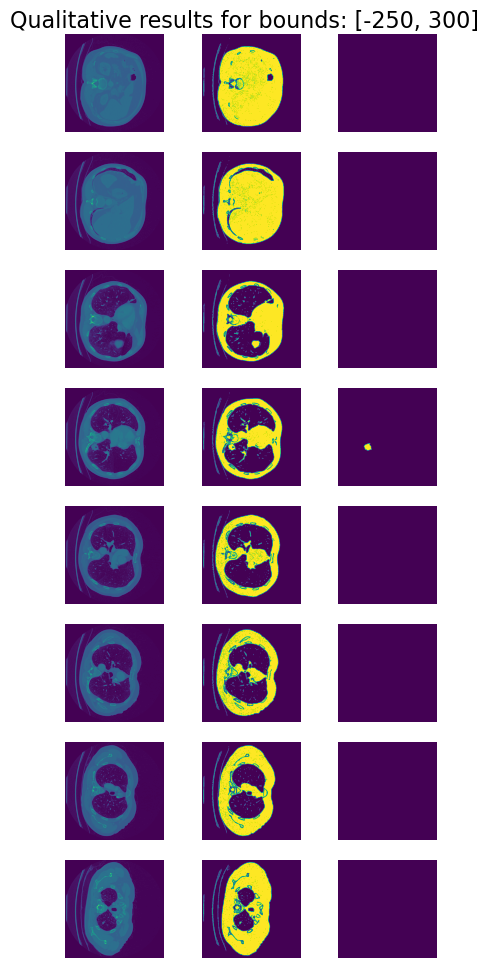

In [77]:
fig, ax = plt.subplots(8, 3, figsize=(5, 12))

step  = val_dataset[i]['image'].shape[-1] // 8

for j in range(8):
    ax[j, 0].imshow(val_dataset[i]['image'][0, :, :, j * step])
    ax[j, 1].imshow(filtered_patient[0, :, :, j * step])
    ax[j, 2].imshow(val_dataset[i]['label'][0, :, :, j * step])

    ax[j, 0].axis('off')
    ax[j, 1].axis('off')
    ax[j, 2].axis('off')


plt.subplots_adjust(wspace=None, hspace=None)
plt.suptitle(f'Qualitative results for bounds: [{low_bound}, {high_bound}]', fontsize=16, y=0.9)
plt.show()